 What is the most common type of surface used in tournaments?

In [17]:
import polars as pl
from pathlib import Path

In [18]:
CURRENT_DIR=Path.cwd()

PROJECT_PATH=CURRENT_DIR.parent

print("project_path:",PROJECT_PATH)

project_path: /Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis


In [19]:
# Search all parquet files in the whole project
all_parquet_files = list(PROJECT_PATH.rglob("*.parquet"))

# Show all found parquet files
all_parquet_files

[PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/D

In [20]:
# List all parquet files in Data folder

data_path = PROJECT_PATH / "tennis_data" / "Data"

parquet_files=list(data_path.rglob("*.parquet"))

for file in parquet_files:
    print(file)
    
    
print("\nData_path:",data_path)

print("\nfolder exists:",data_path.exists())

/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/venue_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/o

In [21]:
for file in all_parquet_files:
    try:
        df = pl.read_parquet(file, n_rows=1)
        for col in df.columns:
            if "surface" in col.lower() or "ground" in col.lower():
                print(file.name, "---->", col)
    except:
        pass

tournament_clean.parquet ----> ground_type
tournament_12132843.parquet ----> ground_type
tournament_12128245.parquet ----> ground_type
tournament_12130289.parquet ----> ground_type
tournament_12129627.parquet ----> ground_type
tournament_12131793.parquet ----> ground_type
tournament_12128410.parquet ----> ground_type
tournament_12134074.parquet ----> ground_type
tournament_12127622.parquet ----> ground_type
tournament_12127632.parquet ----> ground_type
tournament_12131371.parquet ----> ground_type
tournament_12130703.parquet ----> ground_type
tournament_12132992.parquet ----> ground_type
tournament_12130156.parquet ----> ground_type
tournament_12127311.parquet ----> ground_type
tournament_12127738.parquet ----> ground_type
tournament_12131894.parquet ----> ground_type
tournament_12127650.parquet ----> ground_type
tournament_12130242.parquet ----> ground_type
tournament_12128237.parquet ----> ground_type
tournament_12129376.parquet ----> ground_type
tournament_12129382.parquet ----> gro

In [22]:
tournament = pl.read_parquet(
    PROJECT_PATH / "tennis_data"/"Data"/"tournament_clean.parquet"
)

tournament.head()

match_id,tournament_id,tournament_name,tournament_slug,tournament_unique_id,tournament_category_name,tournament_category_slug,user_count,ground_type,tennis_points,has_event_player_statistics,crowd_sourcing_enabled,has_performance_graph_feature,display_inverse_home_away_teams,priority,competition_type,snapshot_date
i64,i64,str,str,str,str,str,i64,str,i64,bool,bool,bool,bool,i64,i64,date
11974053,70826,"""Qualifiers""","""qualifiers""",null,"""Davis Cup""","""davis-cup""",6909,null,null,false,false,false,false,0,2,2024-02-01
11974066,70826,"""Qualifiers""","""qualifiers""",null,"""Davis Cup""","""davis-cup""",6909,null,null,false,false,false,false,0,2,2024-02-01
11998445,126168,"""Montpellier, France""","""montpellier-france""",null,"""ATP""","""atp""",2155,"""Hardcourt indoor""",250,false,false,false,false,0,2,2024-02-01
11998446,126168,"""Montpellier, France""","""montpellier-france""",null,"""ATP""","""atp""",2155,"""Hardcourt indoor""",250,false,false,false,false,0,2,2024-02-01
11998447,126168,"""Montpellier, France""","""montpellier-france""",null,"""ATP""","""atp""",2155,"""Hardcourt indoor""",250,false,false,false,false,0,2,2024-02-01


In [23]:
tournament.select(
    "ground_type"
).unique()

ground_type
str
"""Synthetic outdoor"""
null
"""Carpet indoor"""
"""Grass"""
"""Hardcourt indoor"""
"""Red clay indoor"""
"""Red clay"""
"""Green clay"""
"""Hardcourt outdoor"""


In [24]:
surface_count = (
    tournament
    .group_by("ground_type")
    .agg(
        pl.len().alias("tournament_count")
    )
    .sort(
        "tournament_count",
        descending=True
    )
)

surface_count

ground_type,tournament_count
str,u32
"""Hardcourt outdoor""",16959
"""Red clay""",11856
"""Hardcourt indoor""",4741
null,562
"""Red clay indoor""",512
"""Grass""",509
"""Carpet indoor""",276
"""Synthetic outdoor""",226
"""Green clay""",30


In [26]:
surface_count.sort(
    "tournament_count",
    descending=True
)

ground_type,tournament_count
str,u32
"""Hardcourt outdoor""",16959
"""Red clay""",11856
"""Hardcourt indoor""",4741
null,562
"""Red clay indoor""",512
"""Grass""",509
"""Carpet indoor""",276
"""Synthetic outdoor""",226
"""Green clay""",30


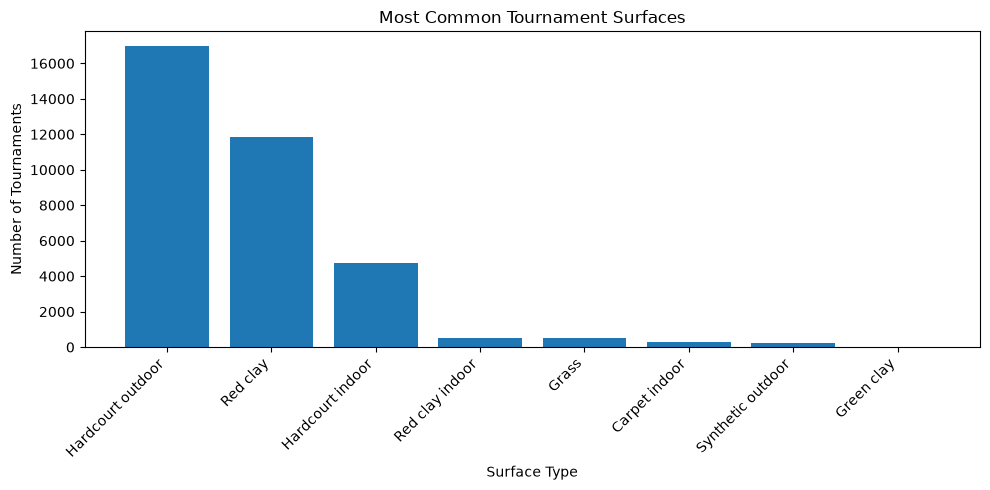

In [27]:
import matplotlib.pyplot as plt

# Remove missing surface values
surface_plot = surface_count.filter(
    pl.col("ground_type").is_not_null()
)

# Convert to pandas for matplotlib
surface_plot_pd = surface_plot.to_pandas()

plt.figure(figsize=(10,5))

plt.bar(
    surface_plot_pd["ground_type"],
    surface_plot_pd["tournament_count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Surface Type")
plt.ylabel("Number of Tournaments")
plt.title("Most Common Tournament Surfaces")

plt.tight_layout()
plt.show()

## Objective
The goal of this analysis is to identify the most frequently used tournament surface type in the tennis dataset.

## Dataset and Feature Selection
The tournament_clean.parquet dataset was used for this analysis.

The relevant column is:

- ground_type: represents the type of surface used in tournaments.

## Data Processing

First, the tournament data was grouped by ground_type and the number of tournaments for each surface type was counted.

Missing surface values were kept separate because they do not represent a specific surface type and were not considered in identifying the most common surface.

## Analysis

The frequency of each surface type was calculated:

- Hardcourt outdoor: 16,959 tournaments
- Red clay: 11,856 tournaments
- Hardcourt indoor: 4,741 tournaments
- Red clay indoor: 512 tournaments
- Grass: 509 tournaments
- Carpet indoor: 276 tournaments
- Synthetic outdoor: 226 tournaments
- Green clay: 30 tournaments

A bar chart was created to visualize the distribution of tournament surfaces.

## Result

The most common tournament surface in the dataset is:

Hardcourt outdoor

with 16,959 recorded tournaments.

This indicates that outdoor hard courts are the most frequently used surface type among the tournaments included in this dataset.